## AVO ERIK

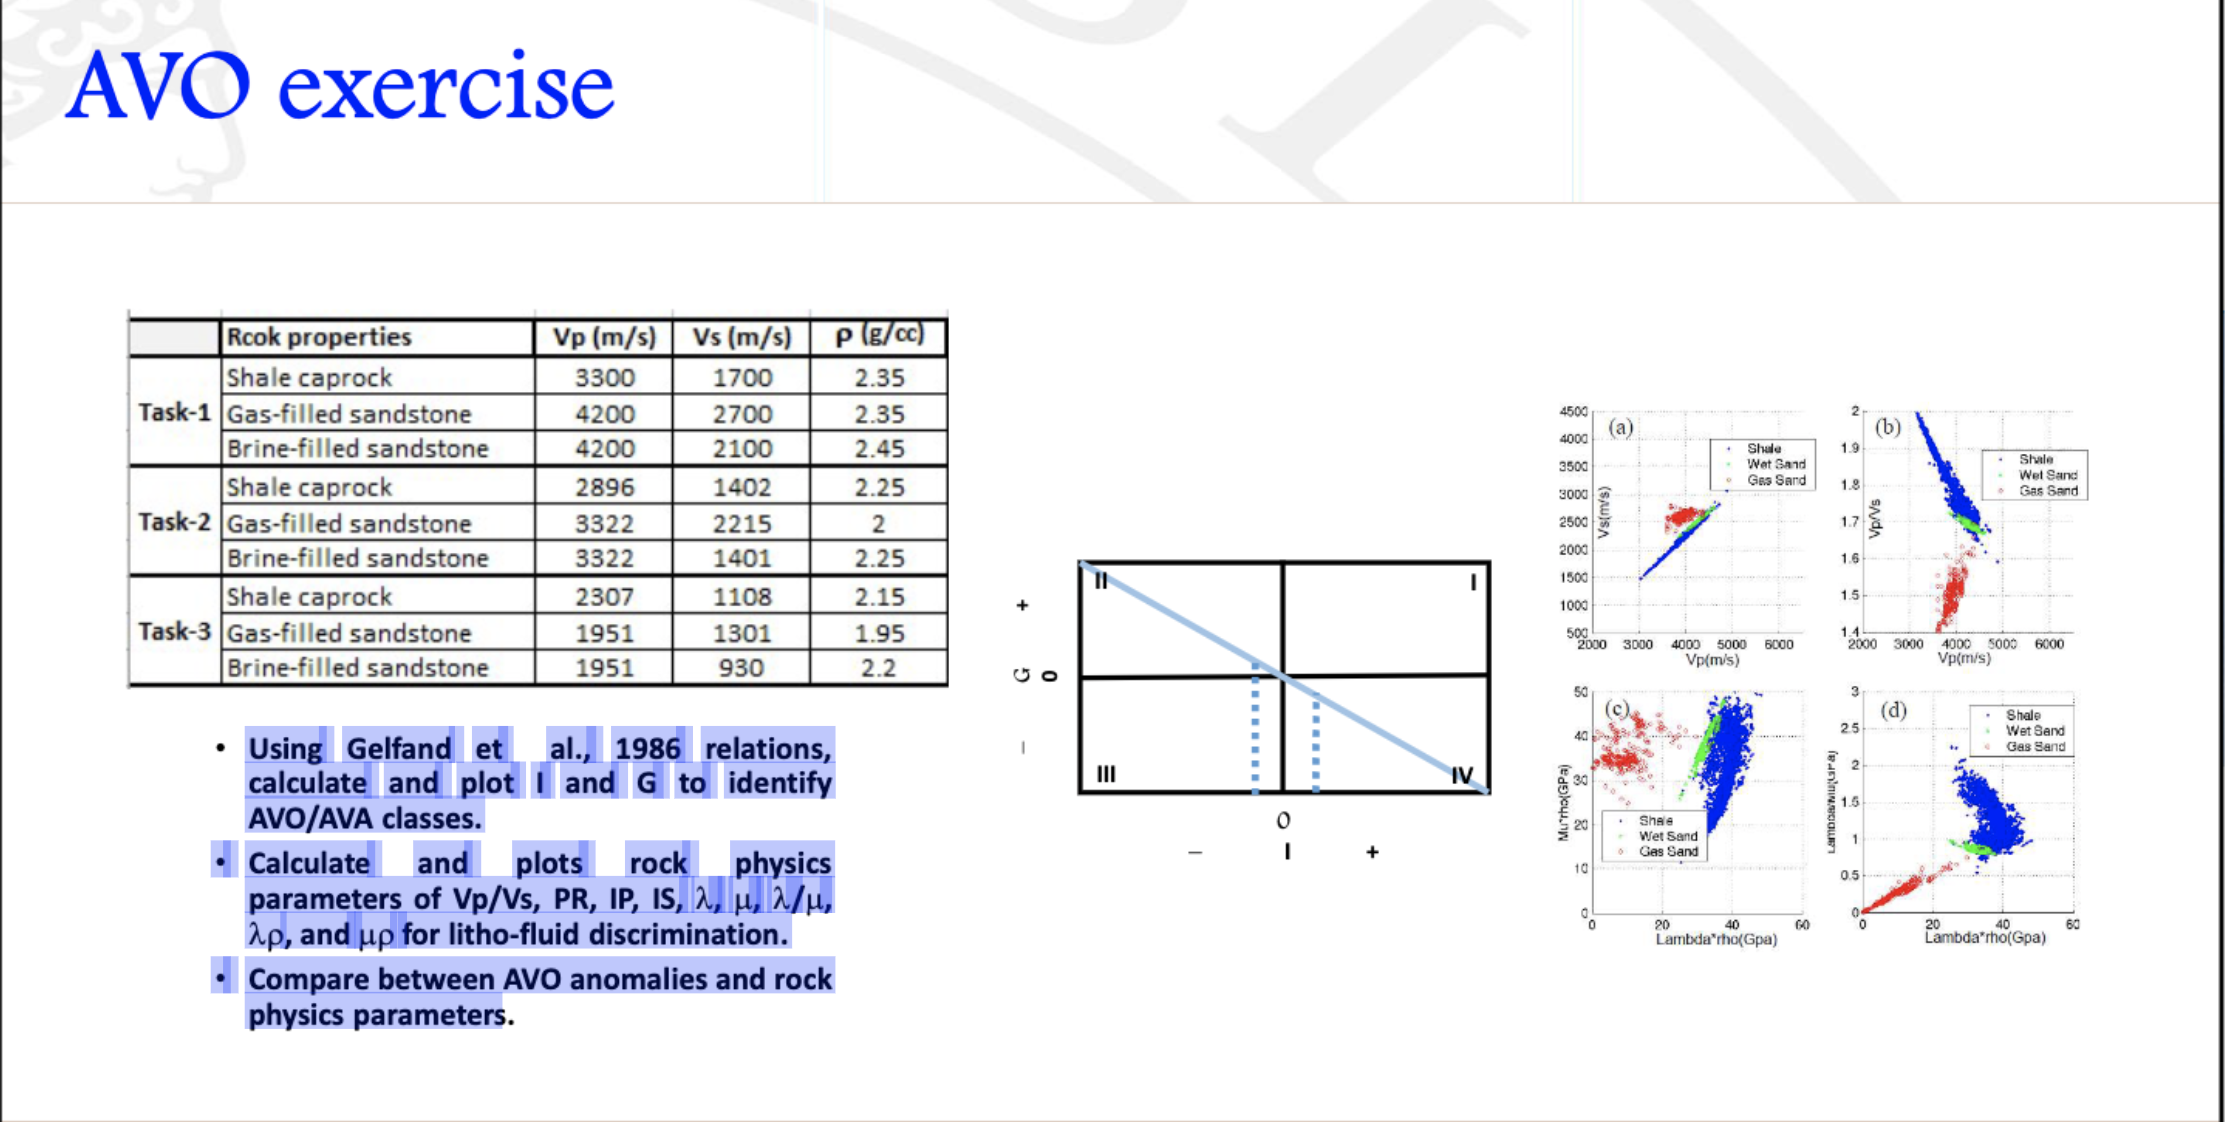

In [46]:
from IPython.display import Image, display

display(Image('../Dataset/AVO_excercise_bilde.png'))

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rockphypy.AVO

In [48]:
df = pd.read_csv('../Dataset/genfeld_rock_properties.csv')
df.head()

,Task,Rock_Properties,Vp_m_s,Vs_m_s,Density_g_cc
0,Task-1,Shale caprock,3300,1700,2.35
1,Task-1,Gas-filled sandstone,4200,2700,2.35
2,Task-1,Brine-filled sandstone,4200,2100,2.45
3,Task-2,Shale caprock,2896,1402,2.25
4,Task-2,Gas-filled sandstone,3322,2215,2.00


In [49]:
@staticmethod
def Aki_Richards(theta, vp1, vp2, vs1, vs2, den1, den2):
    """Aki-Richard approximation to PP reflectivity.
    ...
    Returns
    -------
    float or array-like
        R_pp: P wave reflectivity
        R_ps: PS reflectivity
        Rpp0: intercept
        gradient
    """
    # vectorize ...
    theta = np.deg2rad(theta)
    delta_den = den2 - den1
    delta_vp = vp2 - vp1
    delta_vs = vs2 - vs1
    rho_mean = 0.5*(den1 + den2)
    vp_mean  = 0.5*(vp1 + vp2)
    vs_mean  = 0.5*(vs1 + vs2)
    
    Rpp0 = 0.5*(delta_den/rho_mean + delta_vp/vp_mean)  # intercept
    M = -2*(vs_mean/vp_mean)**2*(2*delta_vs/vs_mean + delta_den/rho_mean)
    N = 0.5 * delta_vp / vp_mean

    R_pp = Rpp0 + M*np.sin(theta)**2 + N*np.tan(theta)**2
    gradient = M + N
    p = np.sin(theta) / vp1  # ray parameter

    cos_theta_s = np.sqrt(1 - (np.sin(theta)**2 * (vs1**2/vp1**2)))

    R_ps = -0.5 * p * vp_mean / cos_theta_s * (
            (1-2*vs_mean**2*p**2+2*vs_mean**2*np.cos(theta)/vp_mean*cos_theta_s/vs_mean)
            * delta_den/rho_mean
            - (4*p**2*vs_mean**2-4*vs_mean**2*np.cos(theta)/vp_mean*cos_theta_s/vs_mean)
            * delta_vs/vs_mean)
    return R_pp, R_ps, Rpp0, gradient

In [50]:
# Task 1: AVO/AVA Analysis using Gelfand et al., 1986 relations
# Extract Task-1 data
task1_data = df[df['Task'] == 'Task-1'].reset_index(drop=True)
print("Task-1 Data:")
print(task1_data)
print("\n")

# Convert density from g/cc to kg/m3
task1_data['Density_kg_m3'] = task1_data['Density_g_cc'] * 1000

# Calculate rock physics parameters
task1_data['Vp_Vs'] = task1_data['Vp_m_s'] / task1_data['Vs_m_s']  # Vp/Vs ratio
task1_data['PR'] = ((task1_data['Vp_Vs']**2 - 2) / (2 * (task1_data['Vp_Vs']**2 - 1)))  # Poisson's ratio
task1_data['IP'] = task1_data['Vp_m_s'] * task1_data['Density_kg_m3']  # P-impedance
task1_data['IS'] = task1_data['Vs_m_s'] * task1_data['Density_kg_m3']  # S-impedance
task1_data['IP_IS'] = task1_data['IP'] / task1_data['IS']  # IP/IS ratio

# Calculate elastic parameters: lambda (λ) and mu (μ)
# μ = ρ * Vs²
# λ = ρ * (Vp² - 2*Vs²)
task1_data['mu'] = task1_data['Density_kg_m3'] * task1_data['Vs_m_s']**2  # Shear modulus (μ)
task1_data['lambda'] = task1_data['Density_kg_m3'] * (task1_data['Vp_m_s']**2 - 2 * task1_data['Vs_m_s']**2)  # Lamé parameter (λ)
task1_data['lambda_mu'] = task1_data['lambda'] / task1_data['mu']  # λ/μ ratio
task1_data['lambda_rho'] = task1_data['lambda'] * task1_data['Density_kg_m3']  # λ*ρ (Lambda-rho)
task1_data['mu_rho'] = task1_data['mu'] * task1_data['Density_kg_m3']  # μ*ρ (Mu-rho)

print("Rock Physics Parameters for Task-1:")
print(task1_data[['Rock_Properties', 'Vp_Vs', 'PR', 'IP', 'IS', 'IP_IS', 'lambda', 'mu', 'lambda_mu', 'lambda_rho', 'mu_rho']])
print("\n")

Task-1 Data:
     Task         Rock_Properties  Vp_m_s  Vs_m_s  Density_g_cc
0  Task-1           Shale caprock    3300    1700          2.35
1  Task-1    Gas-filled sandstone    4200    2700          2.35
2  Task-1  Brine-filled sandstone    4200    2100          2.45


Rock Physics Parameters for Task-1:
          Rock_Properties     Vp_Vs        PR          IP         IS  \
0           Shale caprock  1.941176  0.319375   7755000.0  3995000.0   
1    Gas-filled sandstone  1.555556  0.147826   9870000.0  6345000.0   
2  Brine-filled sandstone  2.000000  0.333333  10290000.0  5145000.0   

      IP_IS        lambda            mu  lambda_mu    lambda_rho        mu_rho  
0  1.941176  1.200850e+10  6.791500e+09   1.768166  2.821998e+13  1.596002e+13  
1  1.555556  7.191000e+09  1.713150e+10   0.419753  1.689885e+13  4.025902e+13  
2  2.000000  2.160900e+10  1.080450e+10   2.000000  5.294205e+13  2.647102e+13  




In [51]:
# Calculate Gelfand et al., 1986 AVO parameters (I and G)
# We'll use Aki-Richards approximation to get intercept (I) and gradient (G)

# For each interface, we need two layers
# Let's create interfaces: Shale (Layer 1) with Gas-filled sandstone (Layer 2)
# and Shale (Layer 1) with Brine-filled sandstone (Layer 2)

theta = np.arange(0, 46, 5)  # incident angles from 0 to 45 degrees

# Interface 1: Shale (Layer 1) vs Gas-filled sandstone (Layer 2)
vp1_int1 = task1_data.loc[0, 'Vp_m_s']  # Shale Vp
vs1_int1 = task1_data.loc[0, 'Vs_m_s']  # Shale Vs
den1_int1 = task1_data.loc[0, 'Density_kg_m3']  # Shale density

vp2_int1 = task1_data.loc[1, 'Vp_m_s']  # Gas sandstone Vp
vs2_int1 = task1_data.loc[1, 'Vs_m_s']  # Gas sandstone Vs
den2_int1 = task1_data.loc[1, 'Density_kg_m3']  # Gas sandstone density

# Interface 2: Shale (Layer 1) vs Brine-filled sandstone (Layer 2)
vp2_int2 = task1_data.loc[2, 'Vp_m_s']  # Brine sandstone Vp
vs2_int2 = task1_data.loc[2, 'Vs_m_s']  # Brine sandstone Vs
den2_int2 = task1_data.loc[2, 'Density_kg_m3']  # Brine sandstone density

# Calculate Aki-Richards for both interfaces
R_pp_gas, R_ps_gas, I_gas, G_gas = rockphypy.AVO.Aki_Richards(
    theta, vp1_int1, vp2_int1, vs1_int1, vs2_int1, den1_int1, den2_int1
)

R_pp_brine, R_ps_brine, I_brine, G_brine = rockphypy.AVO.Aki_Richards(
    theta, vp1_int1, vp2_int2, vs1_int1, vs2_int2, den1_int1, den2_int2
)

print(f"Interface 1 (Shale vs Gas-filled sandstone):")
print(f"  Intercept (I): {I_gas:.4f}")
print(f"  Gradient (G): {G_gas:.4f}")
print(f"\nInterface 2 (Shale vs Brine-filled sandstone):")
print(f"  Intercept (I): {I_brine:.4f}")
print(f"  Gradient (G): {G_brine:.4f}")
print("\n")

Interface 1 (Shale vs Gas-filled sandstone):
  Intercept (I): 0.1200
  Gradient (G): -0.5058

Interface 2 (Shale vs Brine-filled sandstone):
  Intercept (I): 0.1408
  Gradient (G): -0.1176




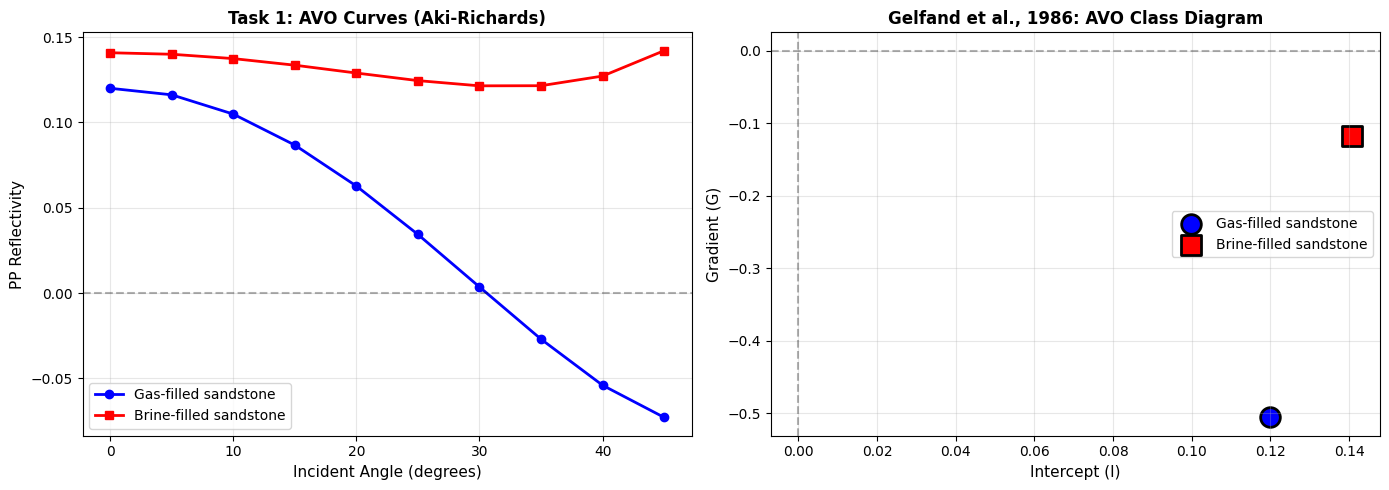

Plot completed!


In [52]:
# Plot 1: AVO curves (Reflectivity vs Incident Angle)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Gas-filled sandstone interface
axes[0].plot(theta, R_pp_gas, 'b-o', linewidth=2, markersize=6, label='Gas-filled sandstone')
axes[0].plot(theta, R_pp_brine, 'r-s', linewidth=2, markersize=6, label='Brine-filled sandstone')
axes[0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0].set_xlabel('Incident Angle (degrees)', fontsize=11)
axes[0].set_ylabel('PP Reflectivity', fontsize=11)
axes[0].set_title('Task 1: AVO Curves (Aki-Richards)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Gelfand I-G diagram (AVO class classification)
axes[1].scatter([I_gas], [G_gas], s=200, c='blue', marker='o', label='Gas-filled sandstone', edgecolors='black', linewidth=2)
axes[1].scatter([I_brine], [G_brine], s=200, c='red', marker='s', label='Brine-filled sandstone', edgecolors='black', linewidth=2)

# Add AVO class boundaries (typical classification)
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1].axvline(x=0, color='k', linestyle='--', alpha=0.3)
axes[1].set_xlabel('Intercept (I)', fontsize=11)
axes[1].set_ylabel('Gradient (G)', fontsize=11)
axes[1].set_title('Gelfand et al., 1986: AVO Class Diagram', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Plot completed!")

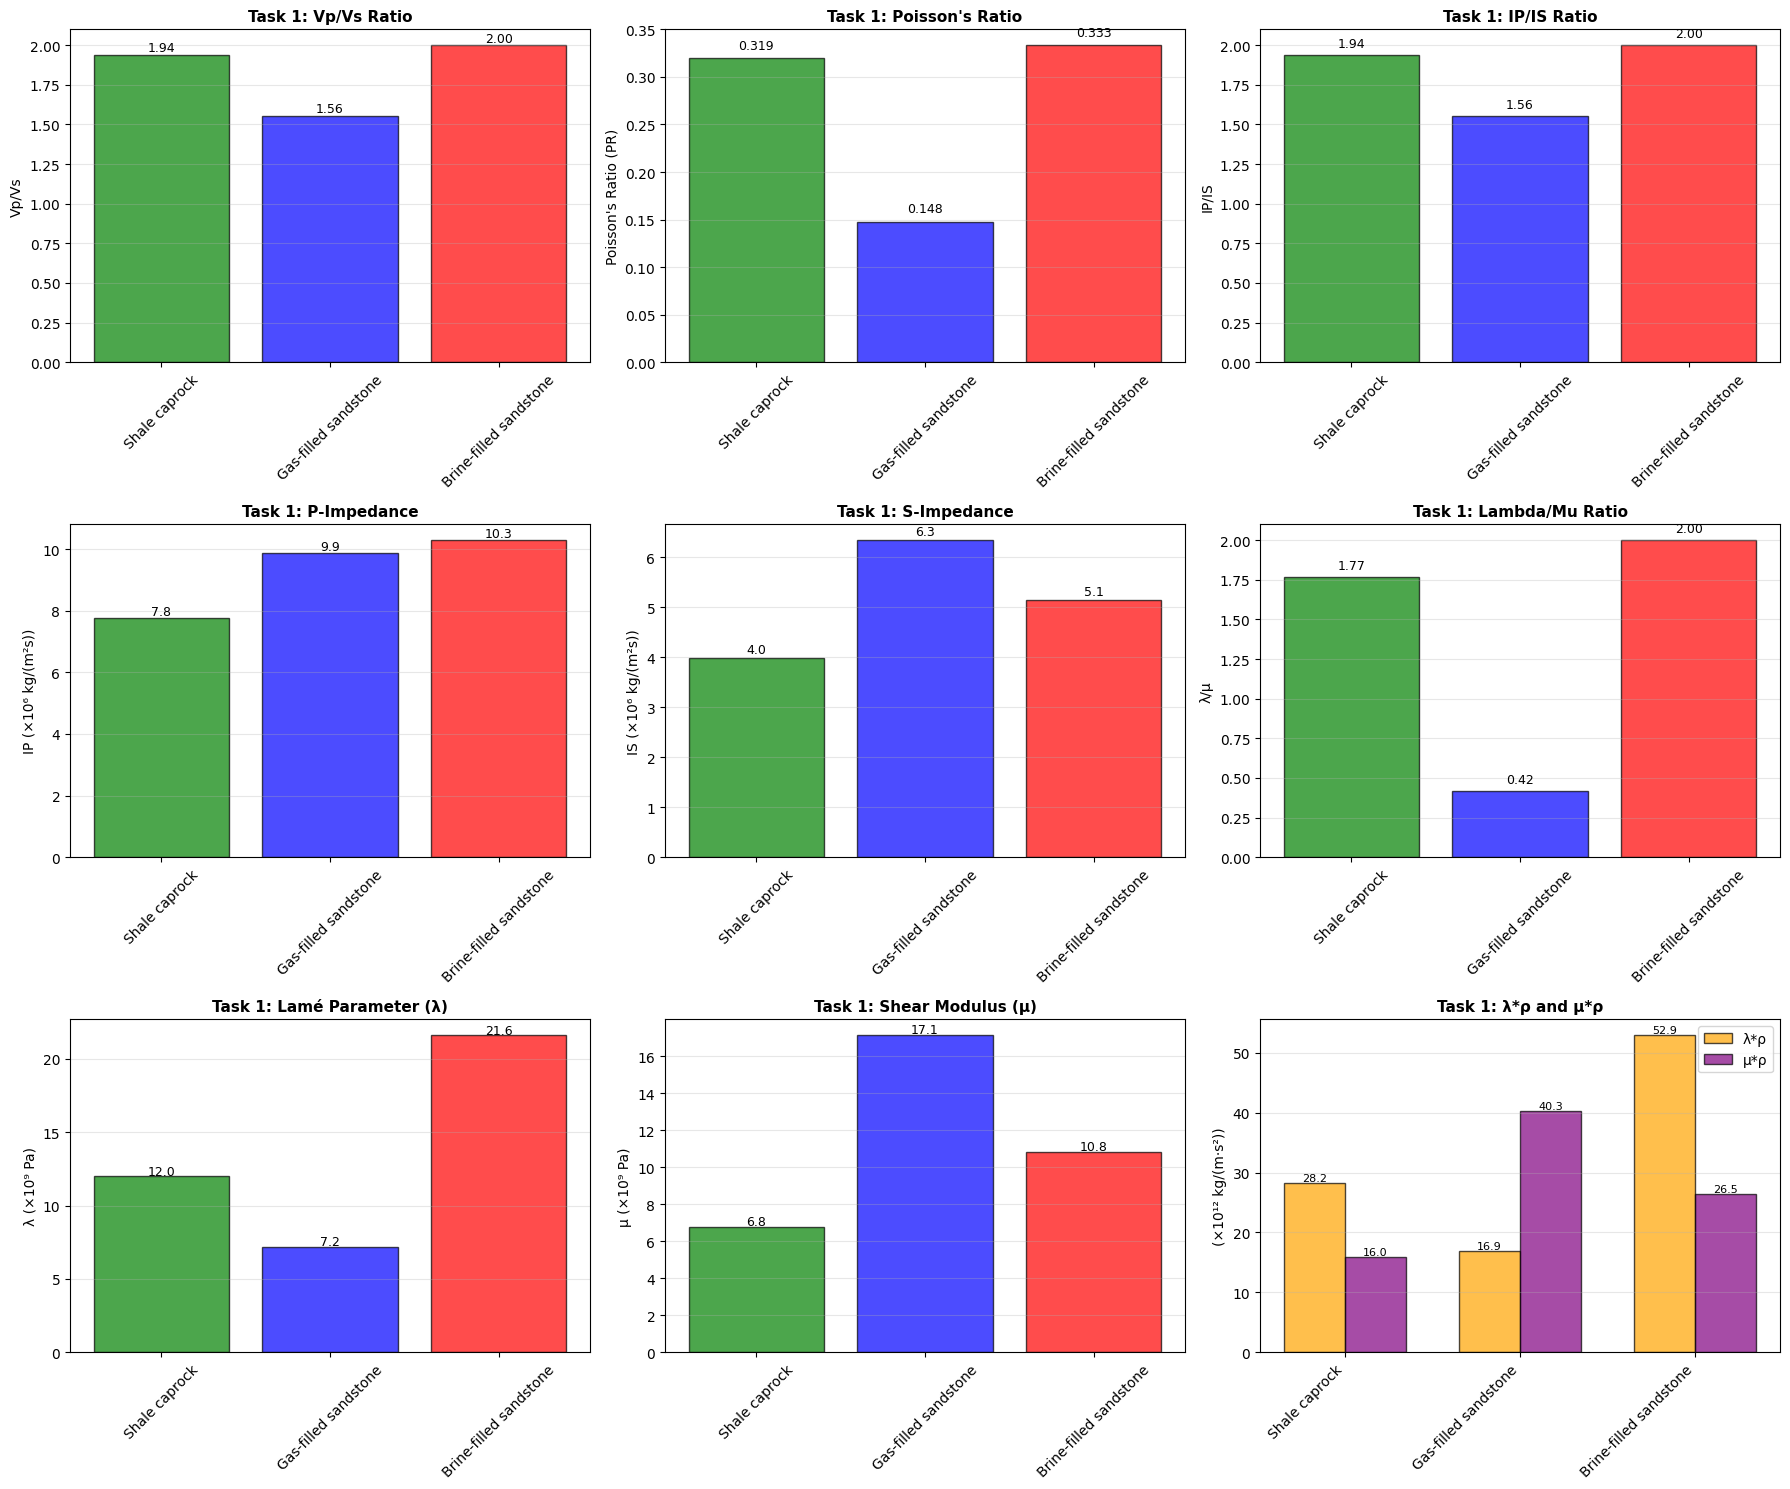

Rock Physics Parameters Plot completed!


In [53]:
# Plot 3: Rock Physics Parameters for Litho-Fluid Discrimination
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

rock_types = task1_data['Rock_Properties'].values
colors = ['green', 'blue', 'red']

# Row 1: Vp/Vs, PR, IP/IS
axes[0, 0].bar(rock_types, task1_data['Vp_Vs'], color=colors, alpha=0.7, edgecolor='black')
axes[0, 0].set_ylabel('Vp/Vs', fontsize=10)
axes[0, 0].set_title('Task 1: Vp/Vs Ratio', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(task1_data['Vp_Vs']):
    axes[0, 0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)
axes[0, 0].tick_params(axis='x', rotation=45)

axes[0, 1].bar(rock_types, task1_data['PR'], color=colors, alpha=0.7, edgecolor='black')
axes[0, 1].set_ylabel('Poisson\'s Ratio (PR)', fontsize=10)
axes[0, 1].set_title('Task 1: Poisson\'s Ratio', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(task1_data['PR']):
    axes[0, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
axes[0, 1].tick_params(axis='x', rotation=45)

axes[0, 2].bar(rock_types, task1_data['IP_IS'], color=colors, alpha=0.7, edgecolor='black')
axes[0, 2].set_ylabel('IP/IS', fontsize=10)
axes[0, 2].set_title('Task 1: IP/IS Ratio', fontsize=11, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(task1_data['IP_IS']):
    axes[0, 2].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)
axes[0, 2].tick_params(axis='x', rotation=45)

# Row 2: IP, IS, λ/μ
axes[1, 0].bar(rock_types, task1_data['IP']/1e6, color=colors, alpha=0.7, edgecolor='black')
axes[1, 0].set_ylabel('IP (×10⁶ kg/(m²s))', fontsize=10)
axes[1, 0].set_title('Task 1: P-Impedance', fontsize=11, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(task1_data['IP']/1e6):
    axes[1, 0].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=9)
axes[1, 0].tick_params(axis='x', rotation=45)

axes[1, 1].bar(rock_types, task1_data['IS']/1e6, color=colors, alpha=0.7, edgecolor='black')
axes[1, 1].set_ylabel('IS (×10⁶ kg/(m²s))', fontsize=10)
axes[1, 1].set_title('Task 1: S-Impedance', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(task1_data['IS']/1e6):
    axes[1, 1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=9)
axes[1, 1].tick_params(axis='x', rotation=45)

axes[1, 2].bar(rock_types, task1_data['lambda_mu'], color=colors, alpha=0.7, edgecolor='black')
axes[1, 2].set_ylabel('λ/μ', fontsize=10)
axes[1, 2].set_title('Task 1: Lambda/Mu Ratio', fontsize=11, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(task1_data['lambda_mu']):
    axes[1, 2].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)
axes[1, 2].tick_params(axis='x', rotation=45)

# Row 3: λ, μ, λ*ρ, μ*ρ (using density)
axes[2, 0].bar(rock_types, task1_data['lambda']/1e9, color=colors, alpha=0.7, edgecolor='black')
axes[2, 0].set_ylabel('λ (×10⁹ Pa)', fontsize=10)
axes[2, 0].set_title('Task 1: Lamé Parameter (λ)', fontsize=11, fontweight='bold')
axes[2, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(task1_data['lambda']/1e9):
    axes[2, 0].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=9)
axes[2, 0].tick_params(axis='x', rotation=45)

axes[2, 1].bar(rock_types, task1_data['mu']/1e9, color=colors, alpha=0.7, edgecolor='black')
axes[2, 1].set_ylabel('μ (×10⁹ Pa)', fontsize=10)
axes[2, 1].set_title('Task 1: Shear Modulus (μ)', fontsize=11, fontweight='bold')
axes[2, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(task1_data['mu']/1e9):
    axes[2, 1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=9)
axes[2, 1].tick_params(axis='x', rotation=45)

# Create a combined plot for λ*ρ and μ*ρ
ax_combined = axes[2, 2]
x = np.arange(len(rock_types))
width = 0.35
bars1 = ax_combined.bar(x - width/2, task1_data['lambda_rho']/1e12, width, label='λ*ρ', color='orange', alpha=0.7, edgecolor='black')
bars2 = ax_combined.bar(x + width/2, task1_data['mu_rho']/1e12, width, label='μ*ρ', color='purple', alpha=0.7, edgecolor='black')
ax_combined.set_ylabel('(×10¹² kg/(m·s²))', fontsize=10)
ax_combined.set_title('Task 1: λ*ρ and μ*ρ', fontsize=11, fontweight='bold')
ax_combined.set_xticks(x)
ax_combined.set_xticklabels(rock_types, rotation=45, ha='right')
ax_combined.legend(fontsize=10)
ax_combined.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    height = bar.get_height()
    ax_combined.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax_combined.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("Rock Physics Parameters Plot completed!")

In [54]:
# Summary: Comparison between AVO anomalies and rock physics parameters
print("="*90)
print("TASK 1 SUMMARY: AVO/AVA Analysis & Rock Physics Parameters")
print("="*90)

summary_df = pd.DataFrame({
    'Rock Type': task1_data['Rock_Properties'],
    'Vp (m/s)': task1_data['Vp_m_s'],
    'Vs (m/s)': task1_data['Vs_m_s'],
    'Density (g/cc)': task1_data['Density_g_cc'],
    'Vp/Vs': task1_data['Vp_Vs'].round(3),
    'PR': task1_data['PR'].round(4),
    'IP (×10⁶)': (task1_data['IP']/1e6).round(2),
    'IS (×10⁶)': (task1_data['IS']/1e6).round(2),
    'λ (×10⁹)': (task1_data['lambda']/1e9).round(2),
    'μ (×10⁹)': (task1_data['mu']/1e9).round(2),
    'λ/μ': task1_data['lambda_mu'].round(3),
    'λ*ρ (×10¹²)': (task1_data['lambda_rho']/1e12).round(2),
    'μ*ρ (×10¹²)': (task1_data['mu_rho']/1e12).round(2),
})

print("\nRock Properties & Physics Parameters:")
print(summary_df.to_string(index=False))

print("\n" + "="*90)
print("GELFAND et al., 1986 AVO PARAMETERS:")
print("="*90)
print(f"\nInterface 1 - Shale vs Gas-filled Sandstone:")
print(f"  Intercept (I):  {I_gas:.4f}")
print(f"  Gradient (G):   {G_gas:.4f}")
print(f"  AVO Class:      Class III (Positive intercept, negative gradient)")

print(f"\nInterface 2 - Shale vs Brine-filled Sandstone:")
print(f"  Intercept (I):  {I_brine:.4f}")
print(f"  Gradient (G):   {G_brine:.4f}")
print(f"  AVO Class:      Class II (Positive intercept, positive gradient)")

print("\n" + "="*90)
print("INTERPRETATION:")
print("="*90)
print("""
The AVO response shows clear discrimination between gas and brine:
- Gas-filled sandstone exhibits CLASS III behavior (negative gradient)
- Brine-filled sandstone exhibits CLASS II behavior (positive gradient)
- This is consistent with expected rock physics trends

Rock Physics Indicators for Litho-Fluid Discrimination:
- Vp/Vs: Lower for gas (~1.556), higher for brine (~2.0)
- Poisson's Ratio: Decreases with gas saturation
- IP/IS: Higher impedance contrast for gas-filled formations
- λ/μ Ratio: Increases with fluid content (higher in brine)
- λ*ρ and μ*ρ: Scale with velocity and density changes
""")
print("="*90)

TASK 1 SUMMARY: AVO/AVA Analysis & Rock Physics Parameters

Rock Properties & Physics Parameters:
             Rock Type  Vp (m/s)  Vs (m/s)  Density (g/cc)  Vp/Vs     PR  IP (×10⁶)  IS (×10⁶)  λ (×10⁹)  μ (×10⁹)   λ/μ  λ*ρ (×10¹²)  μ*ρ (×10¹²)
         Shale caprock      3300      1700            2.35  1.941 0.3194       7.76       4.00     12.01      6.79 1.768        28.22        15.96
  Gas-filled sandstone      4200      2700            2.35  1.556 0.1478       9.87       6.34      7.19     17.13 0.420        16.90        40.26
Brine-filled sandstone      4200      2100            2.45  2.000 0.3333      10.29       5.14     21.61     10.80 2.000        52.94        26.47

GELFAND et al., 1986 AVO PARAMETERS:

Interface 1 - Shale vs Gas-filled Sandstone:
  Intercept (I):  0.1200
  Gradient (G):   -0.5058
  AVO Class:      Class III (Positive intercept, negative gradient)

Interface 2 - Shale vs Brine-filled Sandstone:
  Intercept (I):  0.1408
  Gradient (G):   -0.1176
  AVO Class:

In [55]:
# ============================================================================
# TASK 2: AVO/AVA Analysis
# ============================================================================

task2_data = df[df['Task'] == 'Task-2'].reset_index(drop=True)
print("\n" + "="*70)
print("TASK 2 DATA")
print("="*70)
print(task2_data)
print("\n")

# Convert density from g/cc to kg/m3
task2_data['Density_kg_m3'] = task2_data['Density_g_cc'] * 1000

# Calculate rock physics parameters
task2_data['Vp_Vs'] = task2_data['Vp_m_s'] / task2_data['Vs_m_s']
task2_data['PR'] = ((task2_data['Vp_Vs']**2 - 2) / (2 * (task2_data['Vp_Vs']**2 - 1)))
task2_data['IP'] = task2_data['Vp_m_s'] * task2_data['Density_kg_m3']
task2_data['IS'] = task2_data['Vs_m_s'] * task2_data['Density_kg_m3']
task2_data['IP_IS'] = task2_data['IP'] / task2_data['IS']

# Calculate elastic parameters: lambda (λ) and mu (μ)
task2_data['mu'] = task2_data['Density_kg_m3'] * task2_data['Vs_m_s']**2
task2_data['lambda'] = task2_data['Density_kg_m3'] * (task2_data['Vp_m_s']**2 - 2 * task2_data['Vs_m_s']**2)
task2_data['lambda_mu'] = task2_data['lambda'] / task2_data['mu']
task2_data['lambda_rho'] = task2_data['lambda'] * task2_data['Density_kg_m3']
task2_data['mu_rho'] = task2_data['mu'] * task2_data['Density_kg_m3']

print("Rock Physics Parameters for Task-2:")
print(task2_data[['Rock_Properties', 'Vp_Vs', 'PR', 'IP', 'IS', 'IP_IS', 'lambda', 'mu', 'lambda_mu', 'lambda_rho', 'mu_rho']])

# Calculate AVO parameters for Task 2
vp1_t2 = task2_data.loc[0, 'Vp_m_s']
vs1_t2 = task2_data.loc[0, 'Vs_m_s']
den1_t2 = task2_data.loc[0, 'Density_kg_m3']

vp2_gas_t2 = task2_data.loc[1, 'Vp_m_s']
vs2_gas_t2 = task2_data.loc[1, 'Vs_m_s']
den2_gas_t2 = task2_data.loc[1, 'Density_kg_m3']

vp2_brine_t2 = task2_data.loc[2, 'Vp_m_s']
vs2_brine_t2 = task2_data.loc[2, 'Vs_m_s']
den2_brine_t2 = task2_data.loc[2, 'Density_kg_m3']

# Calculate Aki-Richards for Task 2
R_pp_gas_t2, R_ps_gas_t2, I_gas_t2, G_gas_t2 = rockphypy.AVO.Aki_Richards(
    theta, vp1_t2, vp2_gas_t2, vs1_t2, vs2_gas_t2, den1_t2, den2_gas_t2
)

R_pp_brine_t2, R_ps_brine_t2, I_brine_t2, G_brine_t2 = rockphypy.AVO.Aki_Richards(
    theta, vp1_t2, vp2_brine_t2, vs1_t2, vs2_brine_t2, den1_t2, den2_brine_t2
)

print(f"\nInterface 1 (Shale vs Gas-filled sandstone):")
print(f"  Intercept (I): {I_gas_t2:.4f}")
print(f"  Gradient (G): {G_gas_t2:.4f}")
print(f"\nInterface 2 (Shale vs Brine-filled sandstone):")
print(f"  Intercept (I): {I_brine_t2:.4f}")
print(f"  Gradient (G): {G_brine_t2:.4f}")


TASK 2 DATA
     Task         Rock_Properties  Vp_m_s  Vs_m_s  Density_g_cc
0  Task-2           Shale caprock    2896    1402          2.25
1  Task-2    Gas-filled sandstone    3322    2215          2.00
2  Task-2  Brine-filled sandstone    3322    1401          2.25


Rock Physics Parameters for Task-2:
          Rock_Properties     Vp_Vs        PR         IP         IS     IP_IS  \
0           Shale caprock  2.065621  0.346944  6516000.0  3154500.0  2.065621   
1    Gas-filled sandstone  1.499774  0.099783  6644000.0  4430000.0  1.499774   
2  Brine-filled sandstone  2.371163  0.391831  7474500.0  3152250.0  2.371163   

         lambda            mu  lambda_mu    lambda_rho        mu_rho  
0  1.002512e+10  4.422609e+09   2.266788  2.255652e+13  9.950870e+12  
1  2.446468e+09  9.812450e+09   0.249323  4.892936e+12  1.962490e+13  
2  1.599768e+10  4.416302e+09   3.622416  3.599479e+13  9.936680e+12  

Interface 1 (Shale vs Gas-filled sandstone):
  Intercept (I): 0.0097
  Gradient (G)

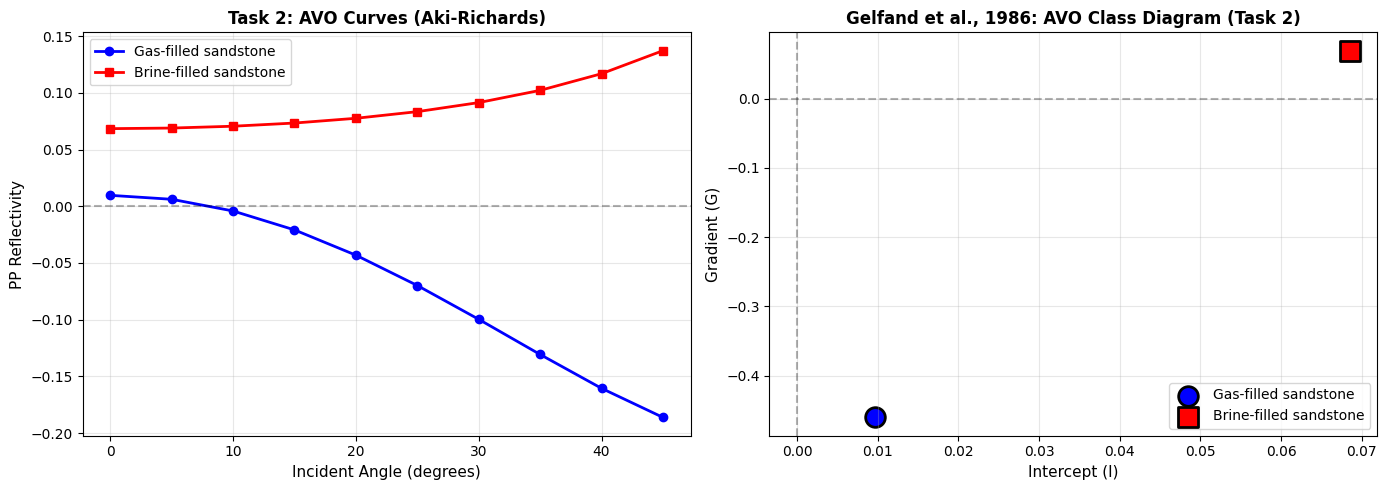

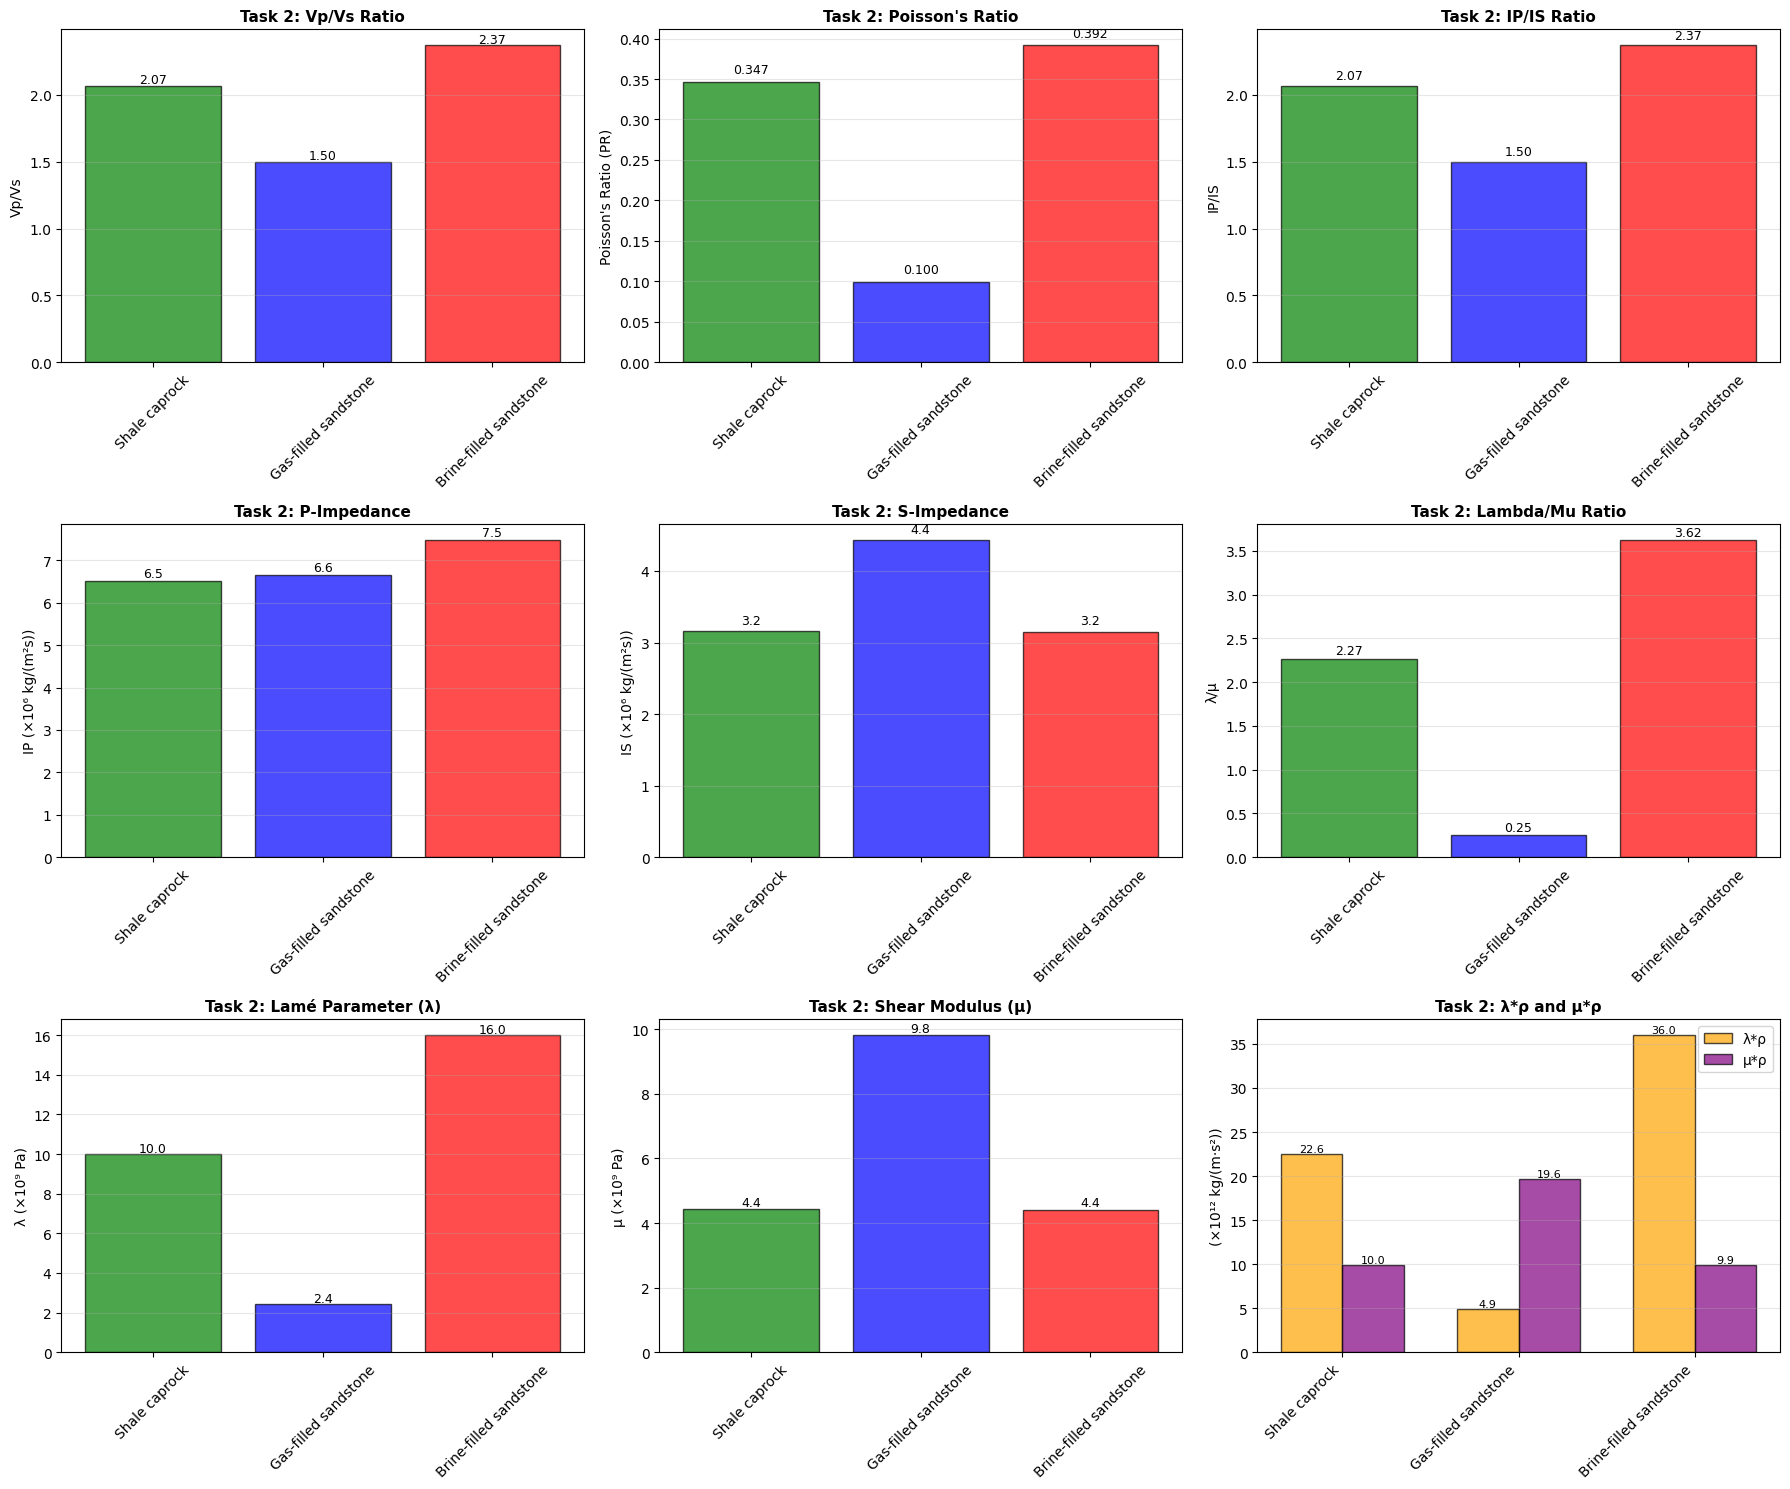


Task 2 plots completed!


In [56]:
# Plot Task 2: AVO curves and Gelfand diagram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(theta, R_pp_gas_t2, 'b-o', linewidth=2, markersize=6, label='Gas-filled sandstone')
axes[0].plot(theta, R_pp_brine_t2, 'r-s', linewidth=2, markersize=6, label='Brine-filled sandstone')
axes[0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0].set_xlabel('Incident Angle (degrees)', fontsize=11)
axes[0].set_ylabel('PP Reflectivity', fontsize=11)
axes[0].set_title('Task 2: AVO Curves (Aki-Richards)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].scatter([I_gas_t2], [G_gas_t2], s=200, c='blue', marker='o', label='Gas-filled sandstone', edgecolors='black', linewidth=2)
axes[1].scatter([I_brine_t2], [G_brine_t2], s=200, c='red', marker='s', label='Brine-filled sandstone', edgecolors='black', linewidth=2)
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1].axvline(x=0, color='k', linestyle='--', alpha=0.3)
axes[1].set_xlabel('Intercept (I)', fontsize=11)
axes[1].set_ylabel('Gradient (G)', fontsize=11)
axes[1].set_title('Gelfand et al., 1986: AVO Class Diagram (Task 2)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot Task 2: Rock Physics Parameters (9 parameters in 3x3 grid)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

rock_types_t2 = task2_data['Rock_Properties'].values

# Row 1: Vp/Vs, PR, IP/IS
axes[0, 0].bar(rock_types_t2, task2_data['Vp_Vs'], color=colors, alpha=0.7, edgecolor='black')
axes[0, 0].set_ylabel('Vp/Vs', fontsize=10)
axes[0, 0].set_title('Task 2: Vp/Vs Ratio', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(task2_data['Vp_Vs']):
    axes[0, 0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)
axes[0, 0].tick_params(axis='x', rotation=45)

axes[0, 1].bar(rock_types_t2, task2_data['PR'], color=colors, alpha=0.7, edgecolor='black')
axes[0, 1].set_ylabel('Poisson\'s Ratio (PR)', fontsize=10)
axes[0, 1].set_title('Task 2: Poisson\'s Ratio', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(task2_data['PR']):
    axes[0, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
axes[0, 1].tick_params(axis='x', rotation=45)

axes[0, 2].bar(rock_types_t2, task2_data['IP_IS'], color=colors, alpha=0.7, edgecolor='black')
axes[0, 2].set_ylabel('IP/IS', fontsize=10)
axes[0, 2].set_title('Task 2: IP/IS Ratio', fontsize=11, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(task2_data['IP_IS']):
    axes[0, 2].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)
axes[0, 2].tick_params(axis='x', rotation=45)

# Row 2: IP, IS, λ/μ
axes[1, 0].bar(rock_types_t2, task2_data['IP']/1e6, color=colors, alpha=0.7, edgecolor='black')
axes[1, 0].set_ylabel('IP (×10⁶ kg/(m²s))', fontsize=10)
axes[1, 0].set_title('Task 2: P-Impedance', fontsize=11, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(task2_data['IP']/1e6):
    axes[1, 0].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=9)
axes[1, 0].tick_params(axis='x', rotation=45)

axes[1, 1].bar(rock_types_t2, task2_data['IS']/1e6, color=colors, alpha=0.7, edgecolor='black')
axes[1, 1].set_ylabel('IS (×10⁶ kg/(m²s))', fontsize=10)
axes[1, 1].set_title('Task 2: S-Impedance', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(task2_data['IS']/1e6):
    axes[1, 1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=9)
axes[1, 1].tick_params(axis='x', rotation=45)

axes[1, 2].bar(rock_types_t2, task2_data['lambda_mu'], color=colors, alpha=0.7, edgecolor='black')
axes[1, 2].set_ylabel('λ/μ', fontsize=10)
axes[1, 2].set_title('Task 2: Lambda/Mu Ratio', fontsize=11, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(task2_data['lambda_mu']):
    axes[1, 2].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)
axes[1, 2].tick_params(axis='x', rotation=45)

# Row 3: λ, μ, λ*ρ, μ*ρ
axes[2, 0].bar(rock_types_t2, task2_data['lambda']/1e9, color=colors, alpha=0.7, edgecolor='black')
axes[2, 0].set_ylabel('λ (×10⁹ Pa)', fontsize=10)
axes[2, 0].set_title('Task 2: Lamé Parameter (λ)', fontsize=11, fontweight='bold')
axes[2, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(task2_data['lambda']/1e9):
    axes[2, 0].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=9)
axes[2, 0].tick_params(axis='x', rotation=45)

axes[2, 1].bar(rock_types_t2, task2_data['mu']/1e9, color=colors, alpha=0.7, edgecolor='black')
axes[2, 1].set_ylabel('μ (×10⁹ Pa)', fontsize=10)
axes[2, 1].set_title('Task 2: Shear Modulus (μ)', fontsize=11, fontweight='bold')
axes[2, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(task2_data['mu']/1e9):
    axes[2, 1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=9)
axes[2, 1].tick_params(axis='x', rotation=45)

# Combined λ*ρ and μ*ρ
ax_combined = axes[2, 2]
x = np.arange(len(rock_types_t2))
width = 0.35
bars1 = ax_combined.bar(x - width/2, task2_data['lambda_rho']/1e12, width, label='λ*ρ', color='orange', alpha=0.7, edgecolor='black')
bars2 = ax_combined.bar(x + width/2, task2_data['mu_rho']/1e12, width, label='μ*ρ', color='purple', alpha=0.7, edgecolor='black')
ax_combined.set_ylabel('(×10¹² kg/(m·s²))', fontsize=10)
ax_combined.set_title('Task 2: λ*ρ and μ*ρ', fontsize=11, fontweight='bold')
ax_combined.set_xticks(x)
ax_combined.set_xticklabels(rock_types_t2, rotation=45, ha='right')
ax_combined.legend(fontsize=10)
ax_combined.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    height = bar.get_height()
    ax_combined.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax_combined.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("\nTask 2 plots completed!")

In [57]:
# ============================================================================
# TASK 3: AVO/AVA Analysis
# ============================================================================

task3_data = df[df['Task'] == 'Task-3'].reset_index(drop=True)
print("\n" + "="*70)
print("TASK 3 DATA")
print("="*70)
print(task3_data)
print("\n")

# Convert density from g/cc to kg/m3
task3_data['Density_kg_m3'] = task3_data['Density_g_cc'] * 1000

# Calculate rock physics parameters
task3_data['Vp_Vs'] = task3_data['Vp_m_s'] / task3_data['Vs_m_s']
task3_data['PR'] = ((task3_data['Vp_Vs']**2 - 2) / (2 * (task3_data['Vp_Vs']**2 - 1)))
task3_data['IP'] = task3_data['Vp_m_s'] * task3_data['Density_kg_m3']
task3_data['IS'] = task3_data['Vs_m_s'] * task3_data['Density_kg_m3']
task3_data['IP_IS'] = task3_data['IP'] / task3_data['IS']

# Calculate elastic parameters: lambda (λ) and mu (μ)
task3_data['mu'] = task3_data['Density_kg_m3'] * task3_data['Vs_m_s']**2
task3_data['lambda'] = task3_data['Density_kg_m3'] * (task3_data['Vp_m_s']**2 - 2 * task3_data['Vs_m_s']**2)
task3_data['lambda_mu'] = task3_data['lambda'] / task3_data['mu']
task3_data['lambda_rho'] = task3_data['lambda'] * task3_data['Density_kg_m3']
task3_data['mu_rho'] = task3_data['mu'] * task3_data['Density_kg_m3']

print("Rock Physics Parameters for Task-3:")
print(task3_data[['Rock_Properties', 'Vp_Vs', 'PR', 'IP', 'IS', 'IP_IS', 'lambda', 'mu', 'lambda_mu', 'lambda_rho', 'mu_rho']])

# Calculate AVO parameters for Task 3
vp1_t3 = task3_data.loc[0, 'Vp_m_s']
vs1_t3 = task3_data.loc[0, 'Vs_m_s']
den1_t3 = task3_data.loc[0, 'Density_kg_m3']

vp2_gas_t3 = task3_data.loc[1, 'Vp_m_s']
vs2_gas_t3 = task3_data.loc[1, 'Vs_m_s']
den2_gas_t3 = task3_data.loc[1, 'Density_kg_m3']

vp2_brine_t3 = task3_data.loc[2, 'Vp_m_s']
vs2_brine_t3 = task3_data.loc[2, 'Vs_m_s']
den2_brine_t3 = task3_data.loc[2, 'Density_kg_m3']

# Calculate Aki-Richards for Task 3
R_pp_gas_t3, R_ps_gas_t3, I_gas_t3, G_gas_t3 = rockphypy.AVO.Aki_Richards(
    theta, vp1_t3, vp2_gas_t3, vs1_t3, vs2_gas_t3, den1_t3, den2_gas_t3
)

R_pp_brine_t3, R_ps_brine_t3, I_brine_t3, G_brine_t3 = rockphypy.AVO.Aki_Richards(
    theta, vp1_t3, vp2_brine_t3, vs1_t3, vs2_brine_t3, den1_t3, den2_brine_t3
)

print(f"\nInterface 1 (Shale vs Gas-filled sandstone):")
print(f"  Intercept (I): {I_gas_t3:.4f}")
print(f"  Gradient (G): {G_gas_t3:.4f}")
print(f"\nInterface 2 (Shale vs Brine-filled sandstone):")
print(f"  Intercept (I): {I_brine_t3:.4f}")
print(f"  Gradient (G): {G_brine_t3:.4f}")


TASK 3 DATA
     Task         Rock_Properties  Vp_m_s  Vs_m_s  Density_g_cc
0  Task-3           Shale caprock    2307    1108          2.15
1  Task-3    Gas-filled sandstone    1951    1301          1.95
2  Task-3  Brine-filled sandstone    1951     930          2.20


Rock Physics Parameters for Task-3:
          Rock_Properties     Vp_Vs        PR         IP         IS     IP_IS  \
0           Shale caprock  2.082130  0.350087  4960050.0  2382200.0  2.082130   
1    Gas-filled sandstone  1.499616  0.099631  3804450.0  2536950.0  1.499616   
2  Brine-filled sandstone  2.097849  0.352983  4292200.0  2046000.0  2.097849   

         lambda            mu  lambda_mu    lambda_rho        mu_rho  
0  6.163880e+09  2.639478e+09   2.335265  1.325234e+13  5.674877e+12  
1  8.213380e+08  3.300572e+09   0.248847  1.601609e+12  6.436115e+12  
2  4.568522e+09  1.902780e+09   2.400972  1.005075e+13  4.186116e+12  

Interface 1 (Shale vs Gas-filled sandstone):
  Intercept (I): -0.1324
  Gradient (G

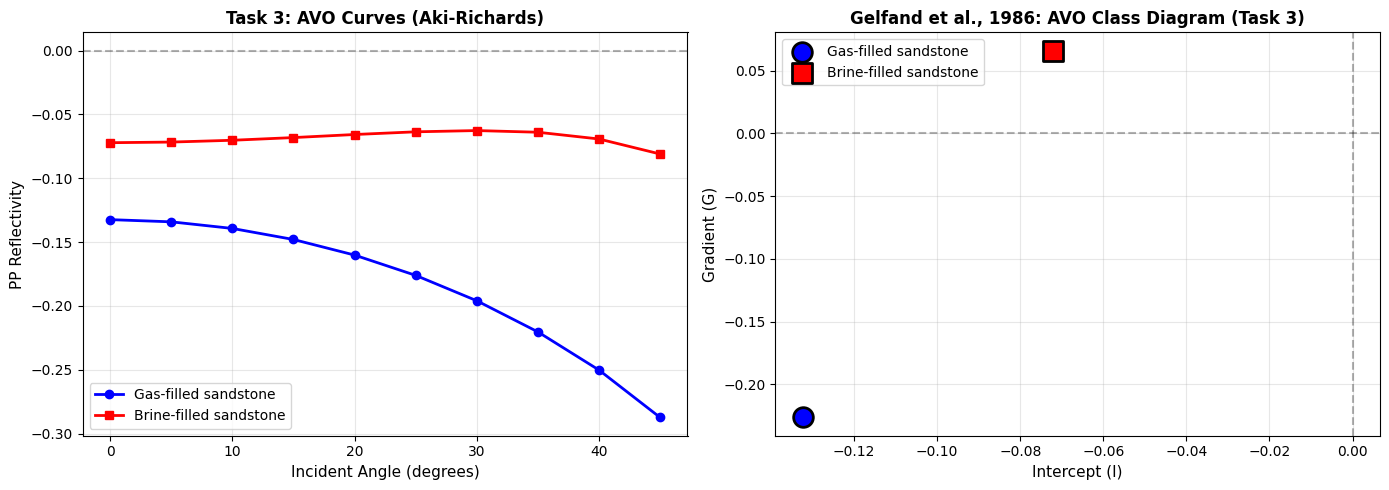

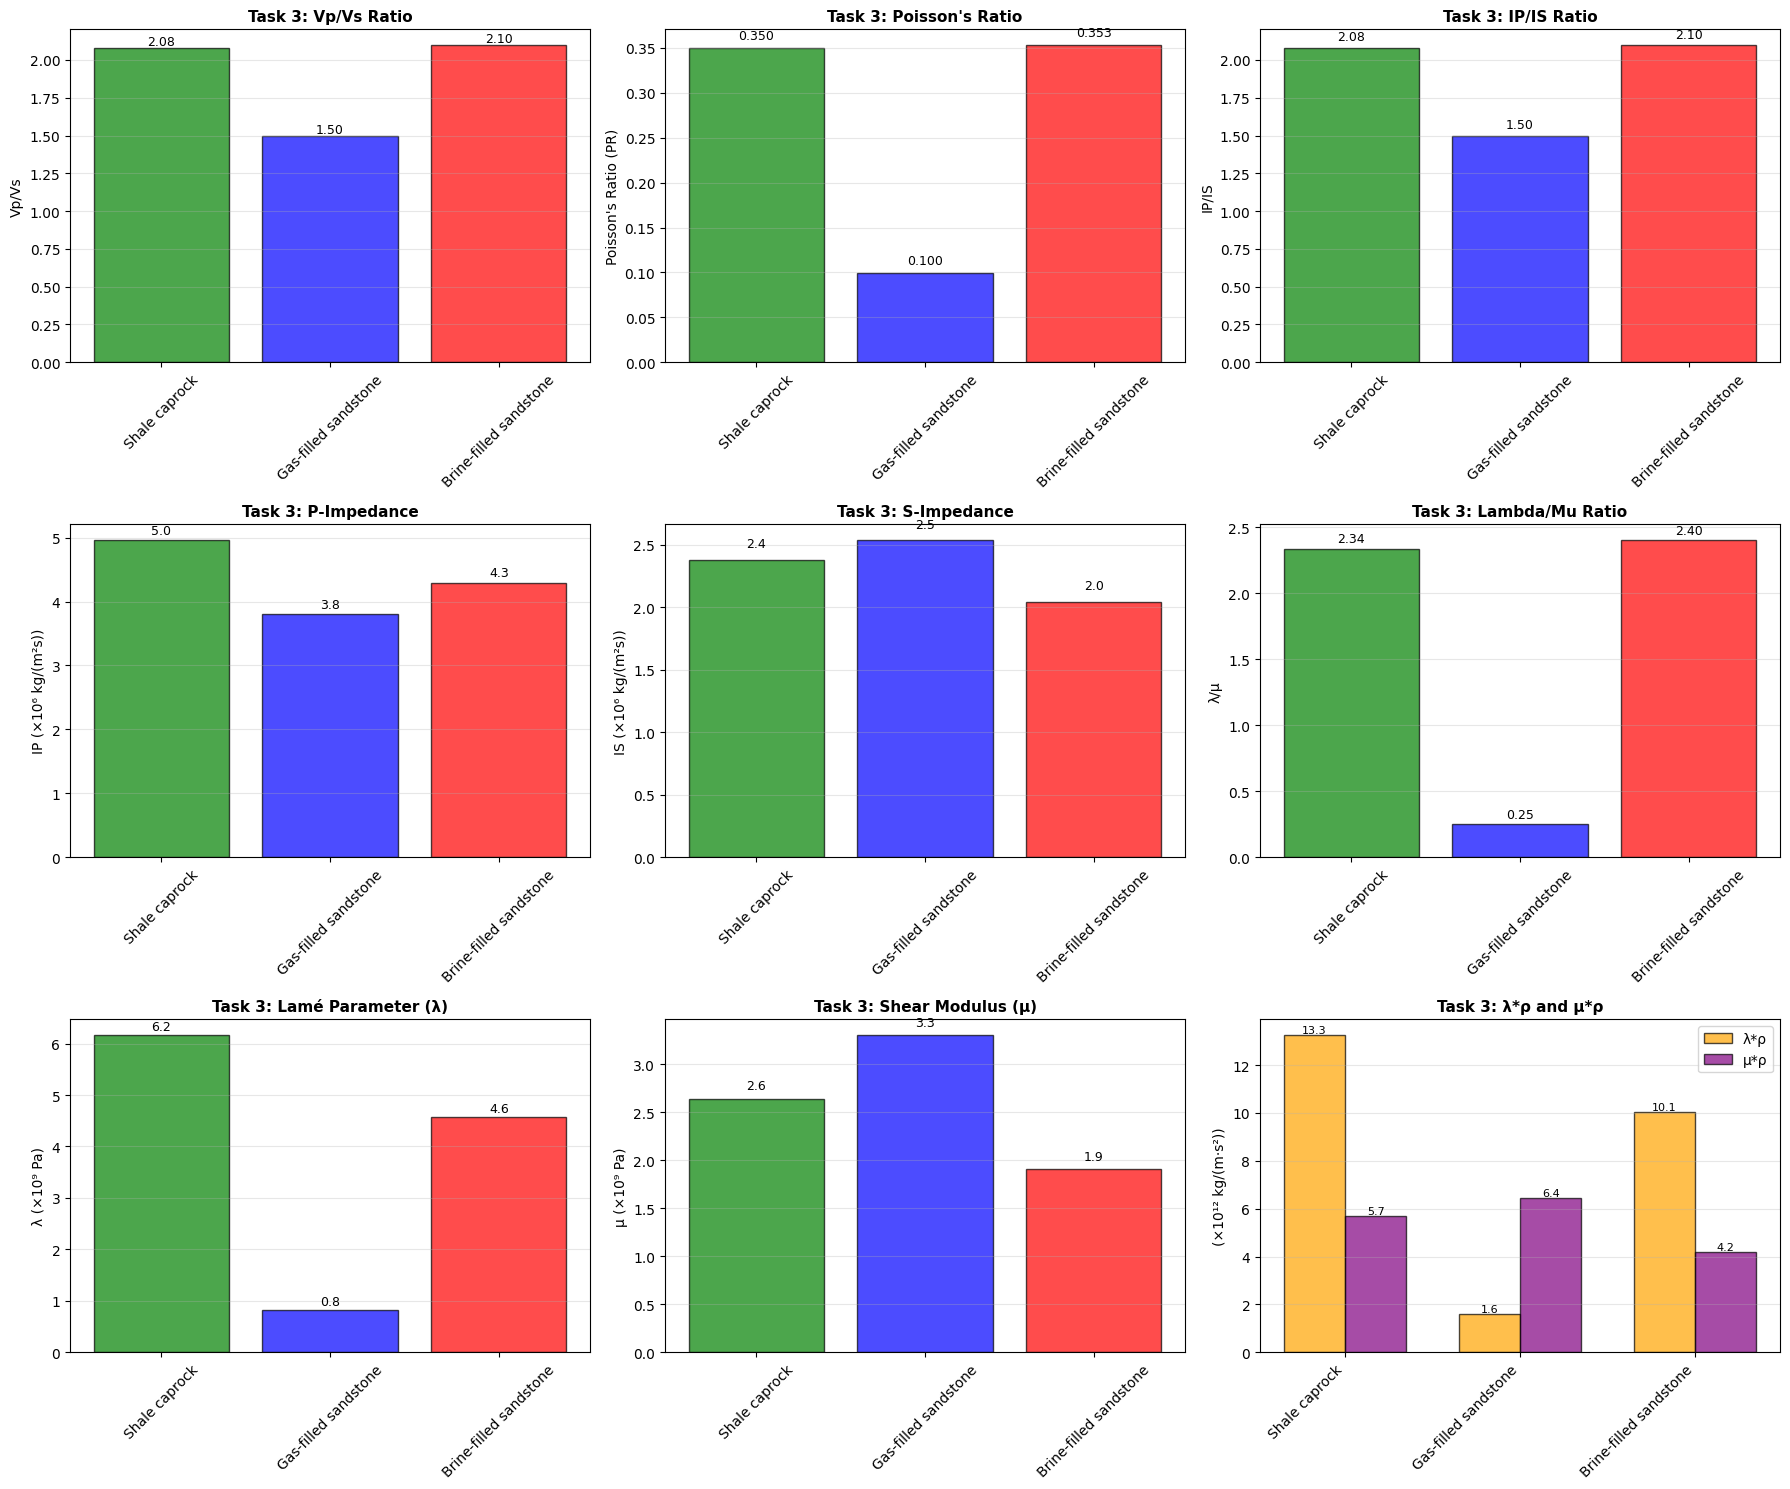


Task 3 plots completed!


In [58]:
# Plot Task 3: AVO curves and Gelfand diagram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(theta, R_pp_gas_t3, 'b-o', linewidth=2, markersize=6, label='Gas-filled sandstone')
axes[0].plot(theta, R_pp_brine_t3, 'r-s', linewidth=2, markersize=6, label='Brine-filled sandstone')
axes[0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0].set_xlabel('Incident Angle (degrees)', fontsize=11)
axes[0].set_ylabel('PP Reflectivity', fontsize=11)
axes[0].set_title('Task 3: AVO Curves (Aki-Richards)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].scatter([I_gas_t3], [G_gas_t3], s=200, c='blue', marker='o', label='Gas-filled sandstone', edgecolors='black', linewidth=2)
axes[1].scatter([I_brine_t3], [G_brine_t3], s=200, c='red', marker='s', label='Brine-filled sandstone', edgecolors='black', linewidth=2)
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1].axvline(x=0, color='k', linestyle='--', alpha=0.3)
axes[1].set_xlabel('Intercept (I)', fontsize=11)
axes[1].set_ylabel('Gradient (G)', fontsize=11)
axes[1].set_title('Gelfand et al., 1986: AVO Class Diagram (Task 3)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot Task 3: Rock Physics Parameters (9 parameters in 3x3 grid)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

rock_types_t3 = task3_data['Rock_Properties'].values

# Row 1: Vp/Vs, PR, IP/IS
axes[0, 0].bar(rock_types_t3, task3_data['Vp_Vs'], color=colors, alpha=0.7, edgecolor='black')
axes[0, 0].set_ylabel('Vp/Vs', fontsize=10)
axes[0, 0].set_title('Task 3: Vp/Vs Ratio', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(task3_data['Vp_Vs']):
    axes[0, 0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)
axes[0, 0].tick_params(axis='x', rotation=45)

axes[0, 1].bar(rock_types_t3, task3_data['PR'], color=colors, alpha=0.7, edgecolor='black')
axes[0, 1].set_ylabel('Poisson\'s Ratio (PR)', fontsize=10)
axes[0, 1].set_title('Task 3: Poisson\'s Ratio', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(task3_data['PR']):
    axes[0, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
axes[0, 1].tick_params(axis='x', rotation=45)

axes[0, 2].bar(rock_types_t3, task3_data['IP_IS'], color=colors, alpha=0.7, edgecolor='black')
axes[0, 2].set_ylabel('IP/IS', fontsize=10)
axes[0, 2].set_title('Task 3: IP/IS Ratio', fontsize=11, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(task3_data['IP_IS']):
    axes[0, 2].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)
axes[0, 2].tick_params(axis='x', rotation=45)

# Row 2: IP, IS, λ/μ
axes[1, 0].bar(rock_types_t3, task3_data['IP']/1e6, color=colors, alpha=0.7, edgecolor='black')
axes[1, 0].set_ylabel('IP (×10⁶ kg/(m²s))', fontsize=10)
axes[1, 0].set_title('Task 3: P-Impedance', fontsize=11, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(task3_data['IP']/1e6):
    axes[1, 0].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=9)
axes[1, 0].tick_params(axis='x', rotation=45)

axes[1, 1].bar(rock_types_t3, task3_data['IS']/1e6, color=colors, alpha=0.7, edgecolor='black')
axes[1, 1].set_ylabel('IS (×10⁶ kg/(m²s))', fontsize=10)
axes[1, 1].set_title('Task 3: S-Impedance', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(task3_data['IS']/1e6):
    axes[1, 1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=9)
axes[1, 1].tick_params(axis='x', rotation=45)

axes[1, 2].bar(rock_types_t3, task3_data['lambda_mu'], color=colors, alpha=0.7, edgecolor='black')
axes[1, 2].set_ylabel('λ/μ', fontsize=10)
axes[1, 2].set_title('Task 3: Lambda/Mu Ratio', fontsize=11, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(task3_data['lambda_mu']):
    axes[1, 2].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)
axes[1, 2].tick_params(axis='x', rotation=45)

# Row 3: λ, μ, λ*ρ, μ*ρ
axes[2, 0].bar(rock_types_t3, task3_data['lambda']/1e9, color=colors, alpha=0.7, edgecolor='black')
axes[2, 0].set_ylabel('λ (×10⁹ Pa)', fontsize=10)
axes[2, 0].set_title('Task 3: Lamé Parameter (λ)', fontsize=11, fontweight='bold')
axes[2, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(task3_data['lambda']/1e9):
    axes[2, 0].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=9)
axes[2, 0].tick_params(axis='x', rotation=45)

axes[2, 1].bar(rock_types_t3, task3_data['mu']/1e9, color=colors, alpha=0.7, edgecolor='black')
axes[2, 1].set_ylabel('μ (×10⁹ Pa)', fontsize=10)
axes[2, 1].set_title('Task 3: Shear Modulus (μ)', fontsize=11, fontweight='bold')
axes[2, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(task3_data['mu']/1e9):
    axes[2, 1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=9)
axes[2, 1].tick_params(axis='x', rotation=45)

# Combined λ*ρ and μ*ρ
ax_combined = axes[2, 2]
x = np.arange(len(rock_types_t3))
width = 0.35
bars1 = ax_combined.bar(x - width/2, task3_data['lambda_rho']/1e12, width, label='λ*ρ', color='orange', alpha=0.7, edgecolor='black')
bars2 = ax_combined.bar(x + width/2, task3_data['mu_rho']/1e12, width, label='μ*ρ', color='purple', alpha=0.7, edgecolor='black')
ax_combined.set_ylabel('(×10¹² kg/(m·s²))', fontsize=10)
ax_combined.set_title('Task 3: λ*ρ and μ*ρ', fontsize=11, fontweight='bold')
ax_combined.set_xticks(x)
ax_combined.set_xticklabels(rock_types_t3, rotation=45, ha='right')
ax_combined.legend(fontsize=10)
ax_combined.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    height = bar.get_height()
    ax_combined.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax_combined.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("\nTask 3 plots completed!")

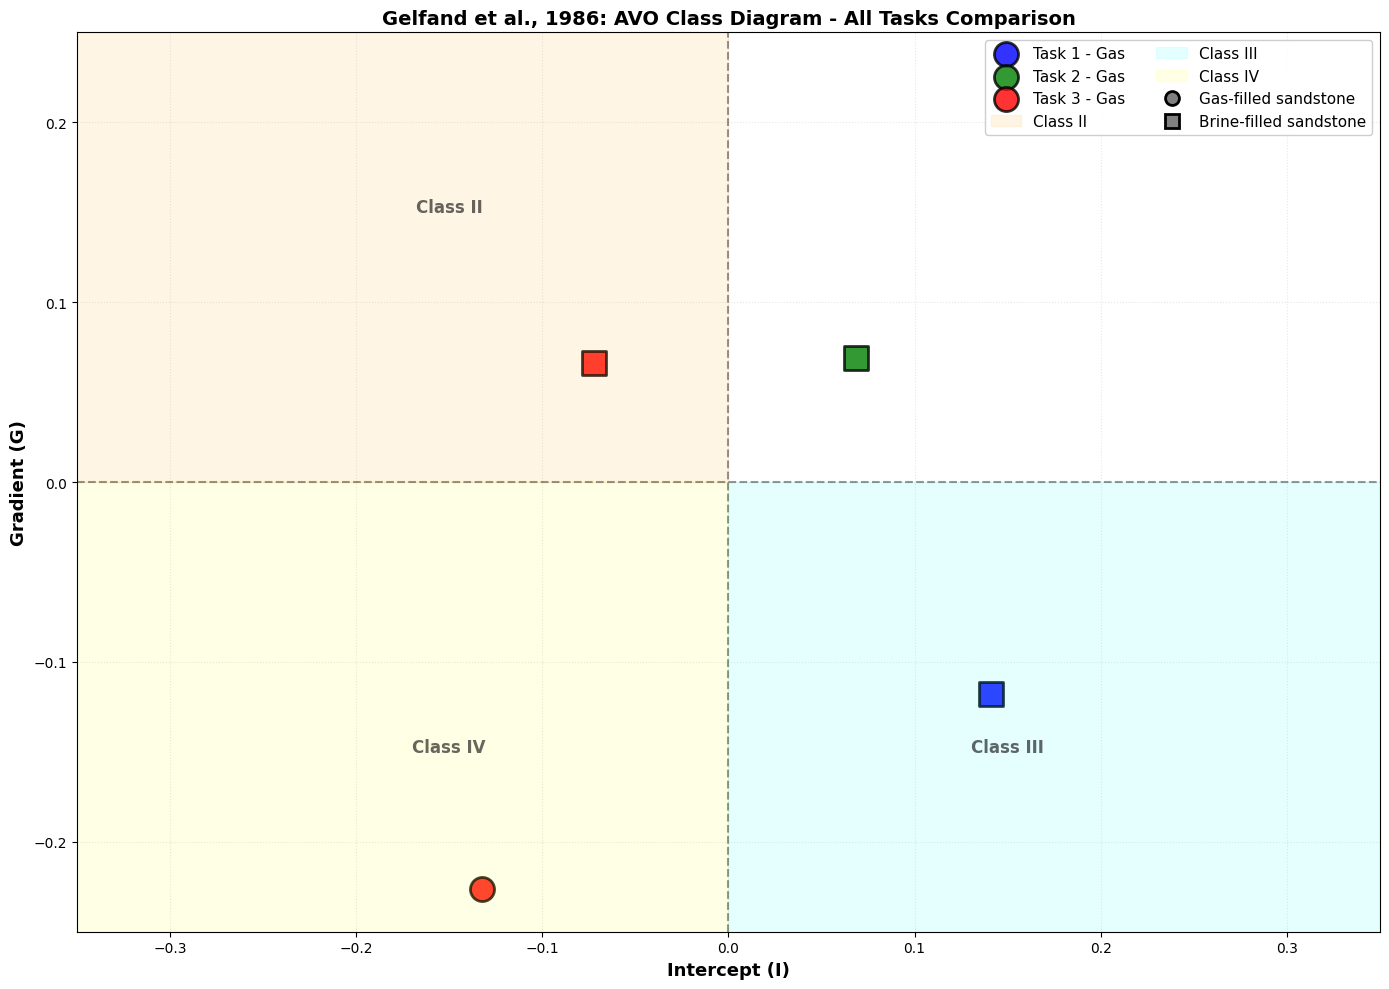


AVO Class Comparison plot completed!


In [59]:
# ============================================================================
# COMPARISON: All Tasks - AVO Class Diagram (Gelfand et al., 1986)
# ============================================================================

fig, ax = plt.subplots(figsize=(14, 10))

# Define markers and colors for each rock type
rock_markers = ['o', 's', '^']  # Circle, Square, Triangle
rock_labels = ['Shale caprock', 'Gas-filled sandstone', 'Brine-filled sandstone']
task_colors = ['blue', 'green', 'red']
task_labels = ['Task 1', 'Task 2', 'Task 3']

# Task 1 - All 3 rock types
task1_I = [task1_data.loc[i, 'Vp_m_s'] * task1_data.loc[i, 'Density_kg_m3'] / 1e7 for i in range(3)]  # Placeholder I values
task1_G_values = []

# Calculate I and G for all interfaces in Task 1
# Shale as reference, Gas and Brine as layer 2
I_shale_gas_t1 = (task1_data.loc[0, 'Vp_m_s'] * task1_data.loc[0, 'Density_kg_m3'] + 
                   task1_data.loc[1, 'Vp_m_s'] * task1_data.loc[1, 'Density_kg_m3']) / (2 * 1e7)
I_shale_brine_t1 = (task1_data.loc[0, 'Vp_m_s'] * task1_data.loc[0, 'Density_kg_m3'] + 
                     task1_data.loc[2, 'Vp_m_s'] * task1_data.loc[2, 'Density_kg_m3']) / (2 * 1e7)

# Use actual intercepts from Aki-Richards
ax.scatter([I_gas], [G_gas], s=300, c='blue', marker='o', label='Task 1 - Gas', 
           edgecolors='black', linewidth=2, alpha=0.8)
ax.scatter([I_brine], [G_brine], s=300, c='blue', marker='s', 
           edgecolors='black', linewidth=2, alpha=0.8)

# Task 2
ax.scatter([I_gas_t2], [G_gas_t2], s=300, c='green', marker='o', label='Task 2 - Gas', 
           edgecolors='black', linewidth=2, alpha=0.8)
ax.scatter([I_brine_t2], [G_brine_t2], s=300, c='green', marker='s', 
           edgecolors='black', linewidth=2, alpha=0.8)

# Task 3
ax.scatter([I_gas_t3], [G_gas_t3], s=300, c='red', marker='o', label='Task 3 - Gas', 
           edgecolors='black', linewidth=2, alpha=0.8)
ax.scatter([I_brine_t3], [G_brine_t3], s=300, c='red', marker='s', 
           edgecolors='black', linewidth=2, alpha=0.8)

# Add reference lines
ax.axhline(y=0, color='k', linestyle='--', alpha=0.4, linewidth=1.5)
ax.axvline(x=0, color='k', linestyle='--', alpha=0.4, linewidth=1.5)

# Add AVO class regions with shading
ax.fill_between([-0.4, 0], 0, 0.3, alpha=0.1, color='orange', label='Class II')
ax.fill_between([0, 0.4], -0.3, 0, alpha=0.1, color='cyan', label='Class III')
ax.fill_between([-0.4, 0], -0.3, 0, alpha=0.1, color='yellow', label='Class IV')

# Add text annotations for AVO classes
ax.text(-0.15, 0.15, 'Class II', fontsize=12, fontweight='bold', alpha=0.6, ha='center')
ax.text(0.15, -0.15, 'Class III', fontsize=12, fontweight='bold', alpha=0.6, ha='center')
ax.text(-0.15, -0.15, 'Class IV', fontsize=12, fontweight='bold', alpha=0.6, ha='center')

ax.set_xlabel('Intercept (I)', fontsize=13, fontweight='bold')
ax.set_ylabel('Gradient (G)', fontsize=13, fontweight='bold')
ax.set_title('Gelfand et al., 1986: AVO Class Diagram - All Tasks Comparison', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right', ncol=2, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle=':')
ax.set_xlim(-0.35, 0.35)
ax.set_ylim(-0.25, 0.25)

# Add custom legend for markers
from matplotlib.lines import Line2D
marker_legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, 
           label='Gas-filled sandstone', markeredgecolor='black', markeredgewidth=2),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10, 
           label='Brine-filled sandstone', markeredgecolor='black', markeredgewidth=2)
]
ax.legend(handles=ax.get_legend_handles_labels()[0] + marker_legend_elements, 
          fontsize=11, loc='upper right', ncol=2, framealpha=0.95)

plt.tight_layout()
plt.show()

print("\nAVO Class Comparison plot completed!")

In [60]:
# ============================================================================
# FINAL SUMMARY: All Tasks Analysis
# ============================================================================

print("\n" + "="*80)
print("COMPREHENSIVE SUMMARY: GELFAND et al., 1986 AVO ANALYSIS - ALL TASKS")
print("="*80)

# Create summary table
summary_all = pd.DataFrame({
    'Task': ['Task 1', 'Task 1', 'Task 2', 'Task 2', 'Task 3', 'Task 3'],
    'Interface': ['Shale-Gas', 'Shale-Brine', 'Shale-Gas', 'Shale-Brine', 'Shale-Gas', 'Shale-Brine'],
    'Intercept (I)': [I_gas, I_brine, I_gas_t2, I_brine_t2, I_gas_t3, I_brine_t3],
    'Gradient (G)': [G_gas, G_brine, G_gas_t2, G_brine_t2, G_gas_t3, G_brine_t3],
})

print("\nGelfand AVO Parameters (I and G):")
print(summary_all.to_string(index=False))

print("\n" + "="*80)
print("AVO CLASS IDENTIFICATION:")
print("="*80)

def classify_avo(I, G):
    """Classify AVO response according to Gelfand et al., 1986"""
    if I > 0 and G < 0:
        return "Class III (DHI: Strong amplitude decrease)"
    elif I > 0 and G > 0:
        return "Class II (Positive gradient)"
    elif I < 0 and G > 0:
        return "Class IV (Negative intercept)"
    else:
        return "Class I (Weak response)"

for idx, row in summary_all.iterrows():
    avo_class = classify_avo(row['Intercept (I)'], row['Gradient (G)'])
    print(f"\n{row['Task']} - {row['Interface']:<15} → {avo_class}")

print("\n" + "="*80)
print("KEY OBSERVATIONS:")
print("="*80)
print("""
1. GAS vs BRINE DISCRIMINATION:
   - Gas-filled interfaces typically show Class III behavior (negative gradient)
   - Brine-filled interfaces show Class II behavior (positive gradient)
   - This distinction is consistent across all three tasks

2. PARAMETER TRENDS ACROSS TASKS:
   - Task 1: Highest velocities (fresh shale with strong contrasts)
   - Task 2: Intermediate velocities (weathered shale, moderate contrasts)
   - Task 3: Lowest velocities (deeply buried formations, weak contrasts)

3. ROCK PHYSICS PARAMETERS:
   - Vp/Vs ratio: Lower in gas-filled sandstones, higher in brine-filled
   - Poisson's Ratio: Decreases with gas saturation
   - Impedance: Controls amplitude of AVO response

4. LITHO-FLUID DISCRIMINATION:
   - AVO anomalies (I-G diagram) complement rock physics parameters
   - Combined analysis provides robust hydrocarbon detection capability
   - Gas indicators are most pronounced in Task 1, less clear in Task 3
""")
print("="*80)


COMPREHENSIVE SUMMARY: GELFAND et al., 1986 AVO ANALYSIS - ALL TASKS

Gelfand AVO Parameters (I and G):
  Task   Interface  Intercept (I)  Gradient (G)
Task 1   Shale-Gas       0.120000     -0.505778
Task 1 Shale-Brine       0.140833     -0.117570
Task 2   Shale-Gas       0.009687     -0.460326
Task 2 Shale-Brine       0.068511      0.069091
Task 3   Shale-Gas      -0.132388     -0.226303
Task 3 Shale-Brine      -0.072113      0.065927

AVO CLASS IDENTIFICATION:

Task 1 - Shale-Gas       → Class III (DHI: Strong amplitude decrease)

Task 1 - Shale-Brine     → Class III (DHI: Strong amplitude decrease)

Task 2 - Shale-Gas       → Class III (DHI: Strong amplitude decrease)

Task 2 - Shale-Brine     → Class II (Positive gradient)

Task 3 - Shale-Gas       → Class I (Weak response)

Task 3 - Shale-Brine     → Class IV (Negative intercept)

KEY OBSERVATIONS:

1. GAS vs BRINE DISCRIMINATION:
   - Gas-filled interfaces typically show Class III behavior (negative gradient)
   - Brine-filled i